In [1]:
import pandas as pd

data = {
    "Hours_Studied": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Exam_Score": [42, 45, 51, 58, 62, 68, 71, 78, 84, 91]
}

df = pd.DataFrame(data)

df

,Hours_Studied,Exam_Score
0,1,42
1,2,45
2,3,51
3,4,58
4,5,62
5,6,68
6,7,71
7,8,78
8,9,84
9,10,91


In [2]:
from sklearn.model_selection import train_test_split

X = df[["Hours_Studied"]]
y = df["Exam_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:")
print(X_train)

print("\nTesting data:")
print(X_test)

Training data:
   Hours_Studied
5              6
0              1
7              8
2              3
9             10
4              5
3              4
6              7

Testing data:
   Hours_Studied
8              9
1              2


In [3]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()

model_lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [4]:
from sklearn.tree import DecisionTreeRegressor

model_tree = DecisionTreeRegressor(random_state=42)

model_tree.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [5]:
lr_predictions = model_lr.predict(X_test)

tree_predictions = model_tree.predict(X_test)

print("Linear Regression predictions:")
print(lr_predictions)

print("\nDecision Tree predictions:")
print(tree_predictions)

print("\nActual scores:")
print(y_test.values)

Linear Regression predictions:
[83.86206897 46.38793103]

Decision Tree predictions:
[78. 42.]

Actual scores:
[84 45]


In [6]:
from sklearn.metrics import mean_absolute_error, r2_score

lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_r2 = r2_score(y_test, lr_predictions)

tree_mae = mean_absolute_error(y_test, tree_predictions)
tree_r2 = r2_score(y_test, tree_predictions)

print("Linear Regression")
print(f"MAE: {lr_mae:.2f}")
print(f"R²: {lr_r2:.2f}")

print("\nDecision Tree")
print(f"MAE: {tree_mae:.2f}")
print(f"R²: {tree_r2:.2f}")

Linear Regression
MAE: 0.76
R²: 1.00

Decision Tree
MAE: 4.50
R²: 0.94


In [7]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree"],
    "MAE": [lr_mae, tree_mae],
    "R²": [lr_r2, tree_r2]
})

comparison

,Model,MAE,R²
0,Linear Regression,0.762931,0.997442
1,Decision Tree,4.500000,0.940828


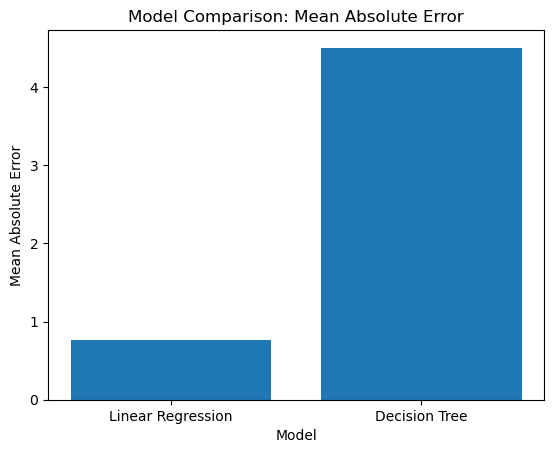

In [8]:
import matplotlib.pyplot as plt

plt.bar(comparison["Model"], comparison["MAE"])

plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")
plt.title("Model Comparison: Mean Absolute Error")

plt.show()

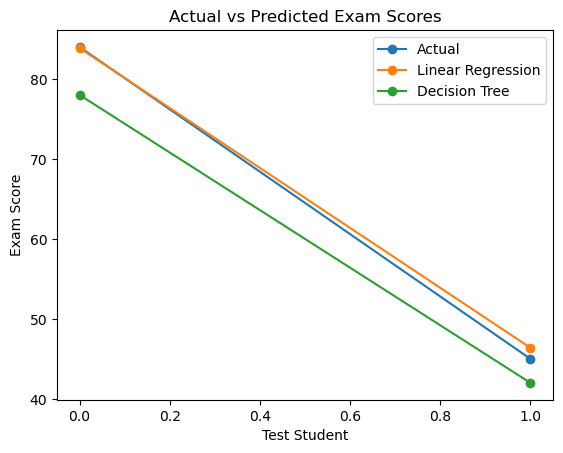

In [9]:
import matplotlib.pyplot as plt

plt.plot(y_test.values, marker="o", label="Actual")
plt.plot(lr_predictions, marker="o", label="Linear Regression")
plt.plot(tree_predictions, marker="o", label="Decision Tree")

plt.xlabel("Test Student")
plt.ylabel("Exam Score")
plt.title("Actual vs Predicted Exam Scores")

plt.legend()

plt.show()

## Conclusion

Two machine learning models were trained and compared: Linear Regression and Decision Tree Regression.

On the test data, Linear Regression produced a lower Mean Absolute Error (MAE) of 0.76 compared with 4.50 for the Decision Tree. Linear Regression also produced a higher R² score of 0.997 compared with 0.941 for the Decision Tree.

This means that, on this particular test split, Linear Regression produced predictions that were closer to the actual exam scores.

However, the dataset was very small, with only 10 observations and 2 test observations. Therefore, these results should not be treated as evidence that Linear Regression will always perform better than a Decision Tree.

This project helped me understand how different machine learning models can be trained, evaluated and compared using MAE and R².